# Plotting

In [1]:
import mammos_units as u
import numpy as np

import mammos_entity as me
import mammos_entity.pyplot as plt

## Same entity, different unit

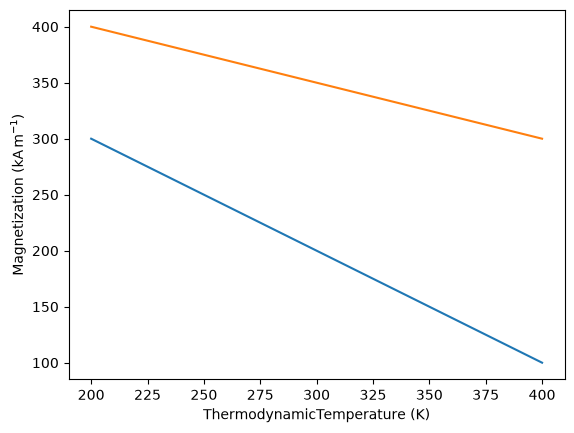

In [2]:
plt.plot(me.T([200, 300, 400]), me.M([300, 200, 100], "kA/m"))
plt.plot(me.T([200, 300, 400]), me.M([0.4, 0.35, 0.3], "MA/m"))

## Reversing order

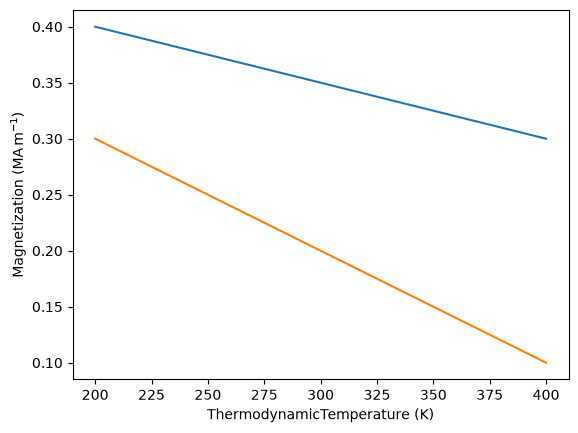

In [3]:
plt.plot(me.T([200, 300, 400]), me.M([0.4, 0.35, 0.3], "MA/m"))
plt.plot(me.T([200, 300, 400]), me.M([300, 200, 100], "kA/m"))

## Conversion errors

ConversionError: Failed to convert value(s) to axis units: array([Entity(ontology_label='MagneticFluxDensity', value=array([250., 250., 250.]), unit='mT')],
      dtype=object)

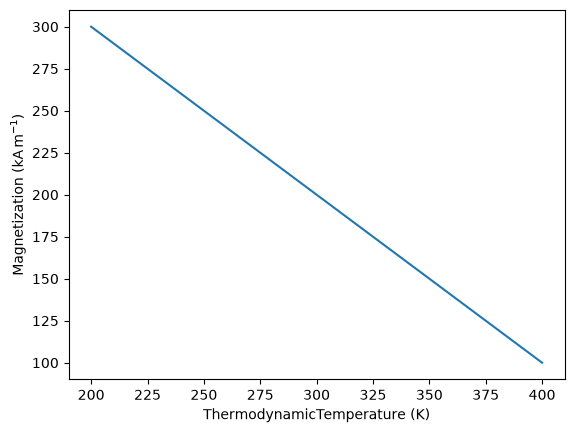

In [4]:
# UnitConversionError
plt.plot(me.T([200, 300, 400]), me.M([300, 200, 100], "kA/m"))
plt.plot(me.T([200, 300, 400]), me.B([250, 250, 250], "mT"))

## No unit

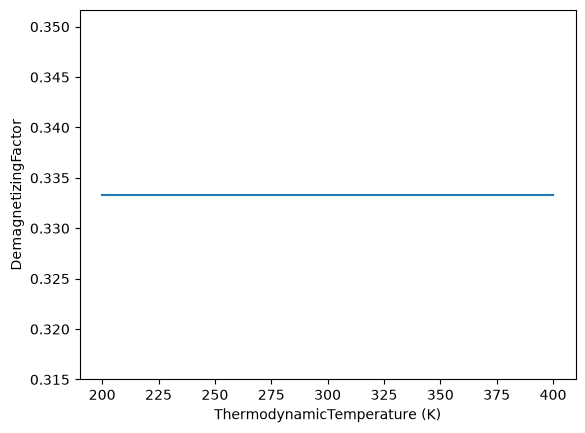

In [5]:
plt.plot(me.T([200, 300, 400]), me.Entity("DemagnetizingFactor", [1/3, 1/3, 1/3]))

## Scaling in units

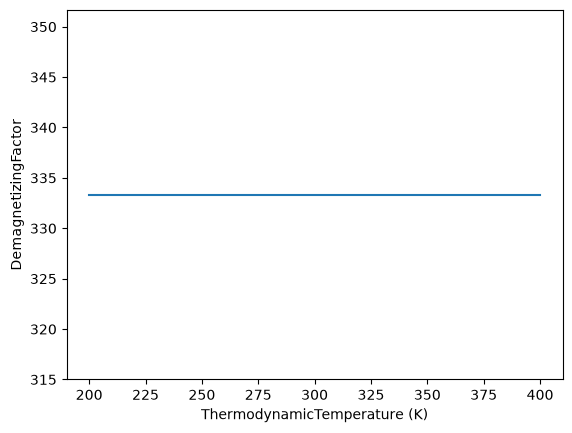

In [6]:
plt.plot(me.T([200, 300, 400]), me.Entity("DemagnetizingFactor", [1/3, 1/3, 1/3], "10e2"))

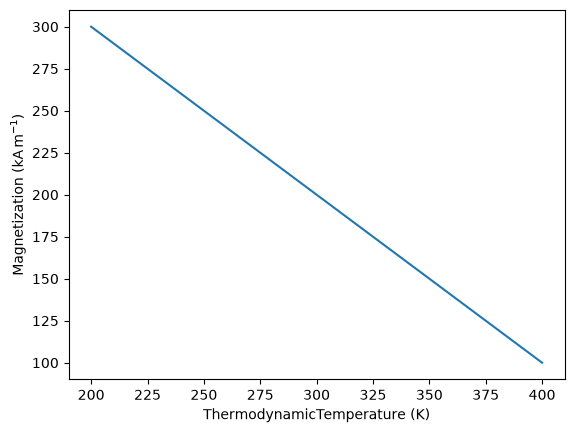

In [7]:
plt.plot(me.T([200, 300, 400]), me.M([0.3, 0.2, 0.1], "1000 kA/m"))

## Using equivalencies

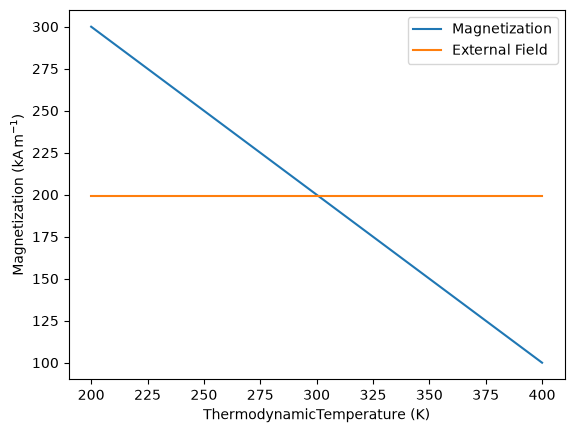

In [8]:
with u.set_enabled_equivalencies(u.magnetic_flux_field()):
    plt.plot(me.T([200, 300, 400]), me.M([300, 200, 100], "kA/m"), label="Magnetization")
    plt.plot(me.T([200, 300, 400]), me.B([250, 250, 250], "mT"), label="External Field")
    plt.legend()

## Quantities

Not possible to plot `Entity`-`Quantity`

In [9]:
import mammos_units as u

import mammos_entity as me
import mammos_entity.pyplot as plt

ValueError: x and y must have same first dimension, but have shapes (1,) and (3,)

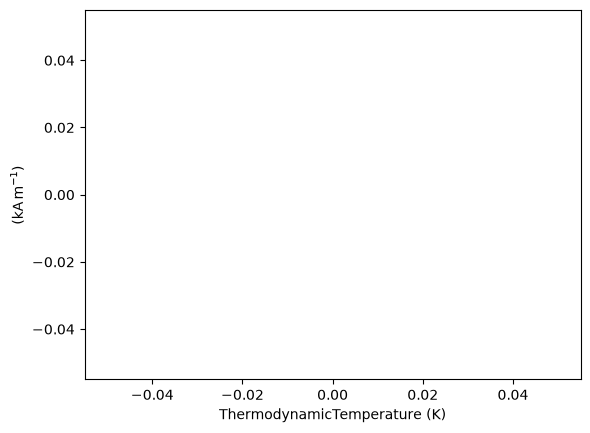

In [10]:
plt.plot(me.T([200, 300, 400]), [200, 400, 200] * u.kA / u.m)

Solution: both quantities.

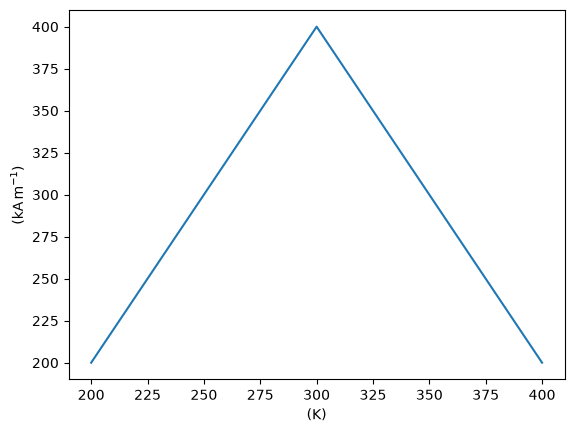

In [11]:
plt.plot(me.T([200, 300, 400]).q, [200, 400, 200] * u.kA / u.m)

Possible to plot `Entity`-`Entity` and `Quantity`-`Quantity` and `Array`-`Array` and `Quantity`-`Array` together.

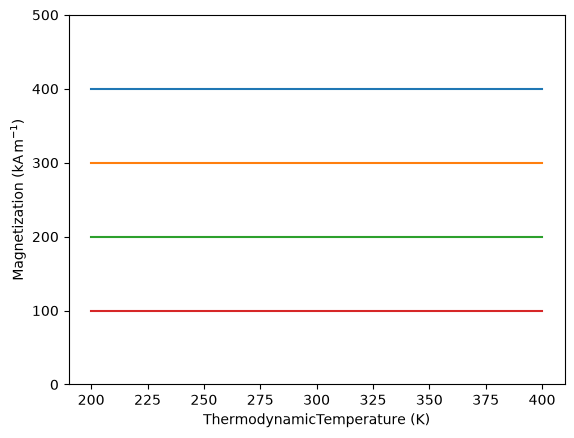

In [12]:
fig, ax = plt.subplots()
ax.plot(me.T([200, 300, 400]), me.M([400, 400, 400], "kA/m"))
ax.plot(me.T([200, 300, 400]).q, [300, 300, 300] * u.kA / u.m)
ax.plot(me.T([200, 300, 400]).value, np.array([200, 200, 200]))
ax.plot(me.T([200, 300, 400]).q, np.array([100, 100, 100]))
ax.set_ylim(0, 500);

But if the first one is not an entity, we lose the label:

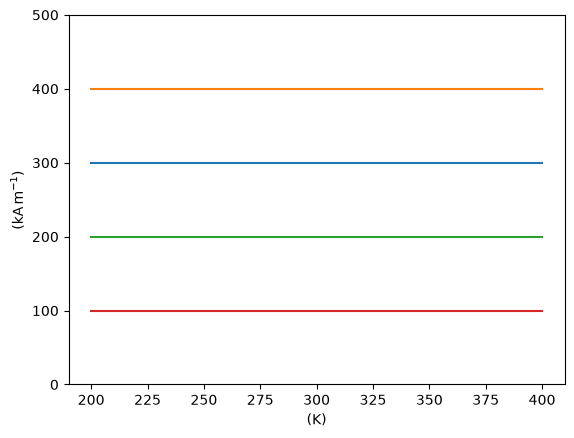

In [13]:
fig, ax = plt.subplots()
ax.plot(me.T([200, 300, 400]).q, [300, 300, 300] * u.kA / u.m)
ax.plot(me.T([200, 300, 400]), me.M([400, 400, 400], "kA/m"))
ax.plot(me.T([200, 300, 400]).value, np.array([200, 200, 200]))
ax.plot(me.T([200, 300, 400]).q, np.array([100, 100, 100]))
ax.set_ylim(0, 500);